# (03) Kyoto16, gaussian-sigmoid: (32, 48.0)

project = ```P-VIB```, host = ```yoru```, device = ```cuda:1```

**Motivation**: <br>

Reproduce

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.analysis import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Larger LR

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs(model_type, 'Kyoto16')

cfg_vae['n_latents'] = 256
cfg_vae['latent_act'] = 'sigmoid'

cfg_vae['seq_len'] = 32
cfg_tr['kl_beta'] = 48.0

cfg_tr['epochs']= 1000

cfg_tr['dataset_kws'] = {
    'file_name': 'patches.npy',
    'shift_rescale': True,
}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |   66.6 K   |
|     ———     |    ———     |
|    layer    |   66.6 K   |
+-------------+------------+

gaussian_sigmoid_Kyoto16_t-32_z-[256]_u-(7,2.3),du-(7,3)_<grad|lin>
b200-ep1000-lr(0.005)_beta(48:0.1)_gr(500)_(2025_03_03,22:34)

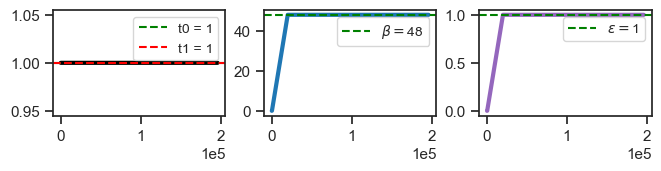

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

196000

In [6]:
tr.model.cfg.init_scale

0.0001

In [7]:
print(tr.model.layer)

GaussianSigmoidLayer(input_dim=256, latent_dim=256, temperature=1, beta_inner=1, eps=1)

In [8]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>),
 tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>))

In [9]:
# cm = f""
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 1000, avg loss: 176.311: 100%|████| 1000/1000 [5:18:12<00:00, 19.09s/it]


epoch # 1000, avg loss: 201.405: 100%|████| 1000/1000 [2:22:20<00:00,  8.54s/it]


In [10]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0493], device='cuda:1', grad_fn=<ExpBackward0>),
 tensor([0.0081], device='cuda:1', grad_fn=<ExpBackward0>))

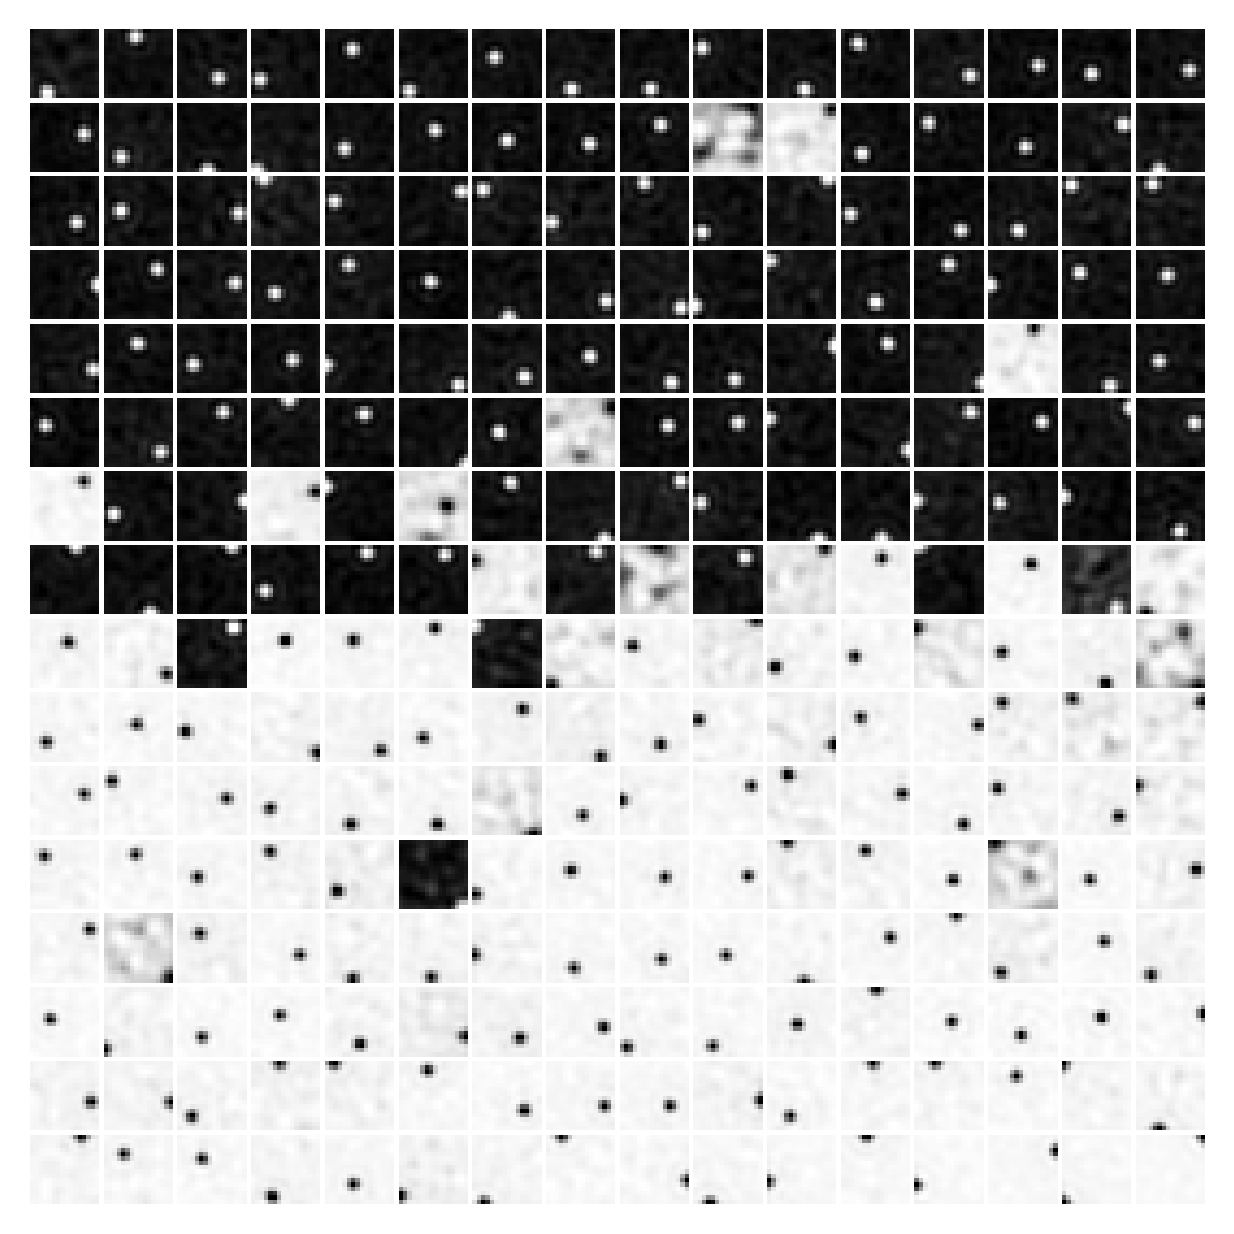

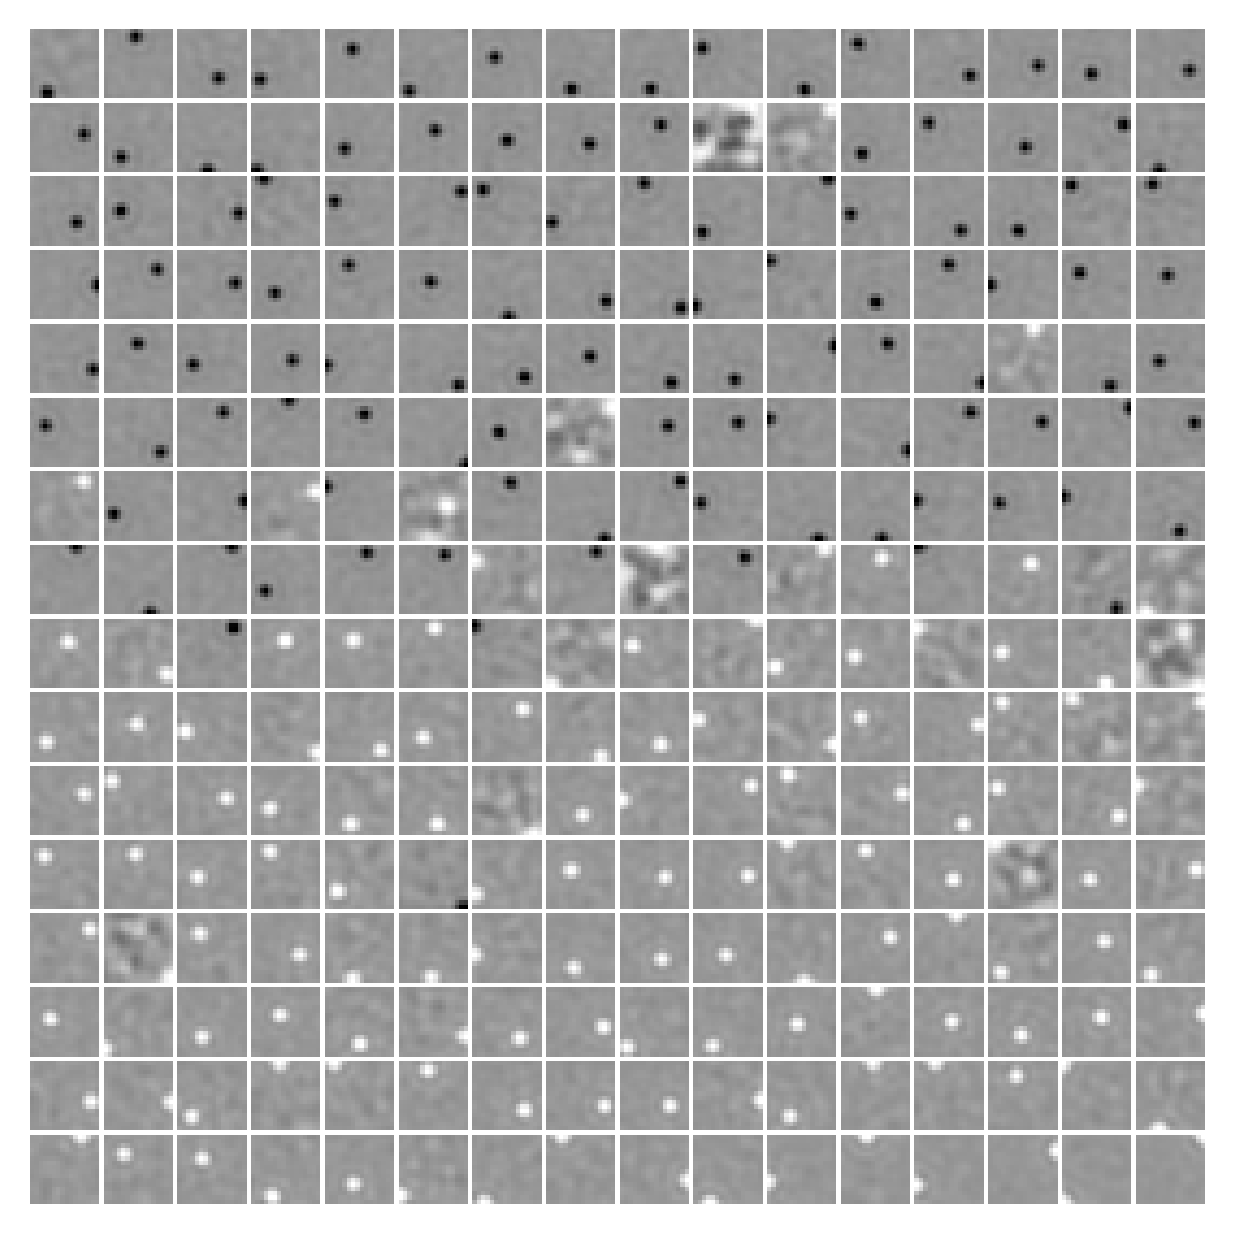

In [21]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=300)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=300, method='abs-max');

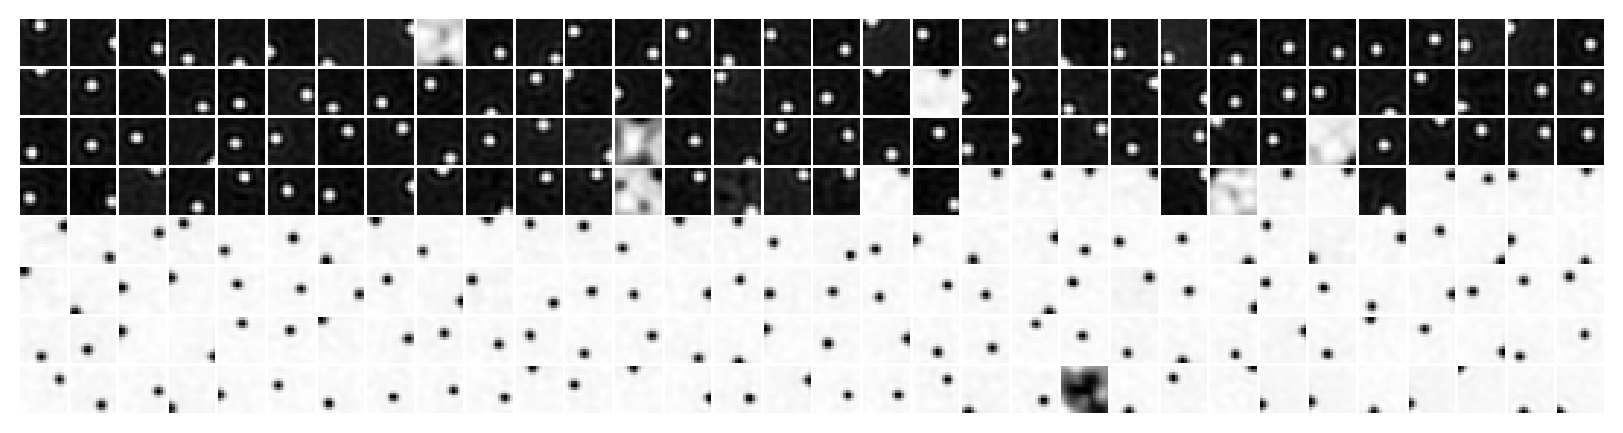

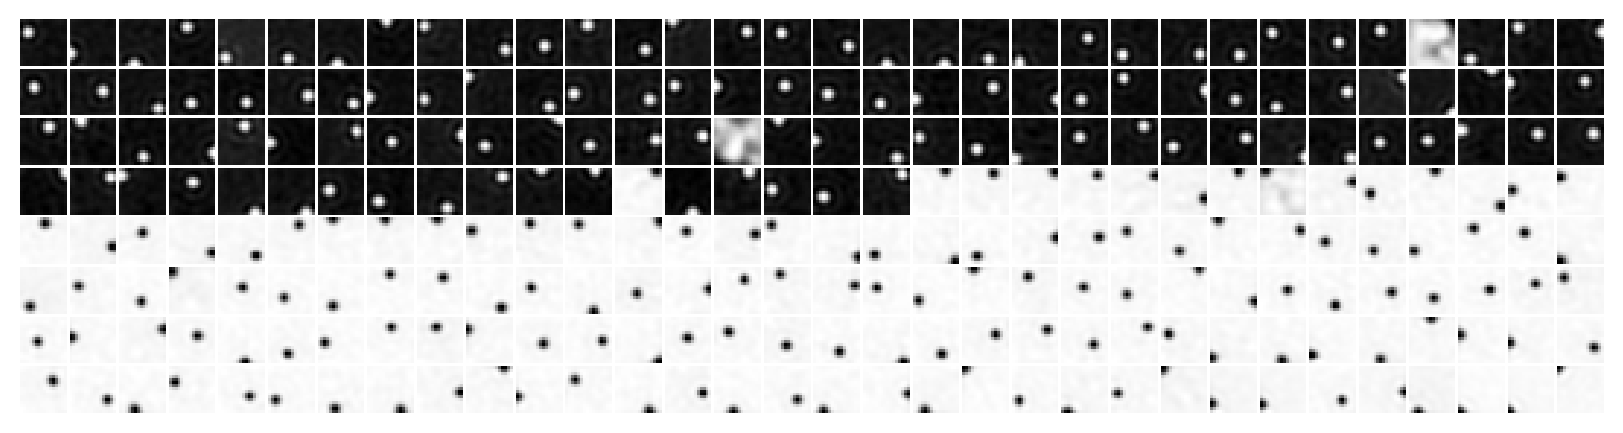

In [12]:
w = tr.model.layer.get_weight().T
absmax = torch.max(w.abs(), dim=1, keepdims=True).values

w_rescaled = 0.5 * (w / absmax + 1)
w_rescaled = w_rescaled.reshape(-1, 16, 16)

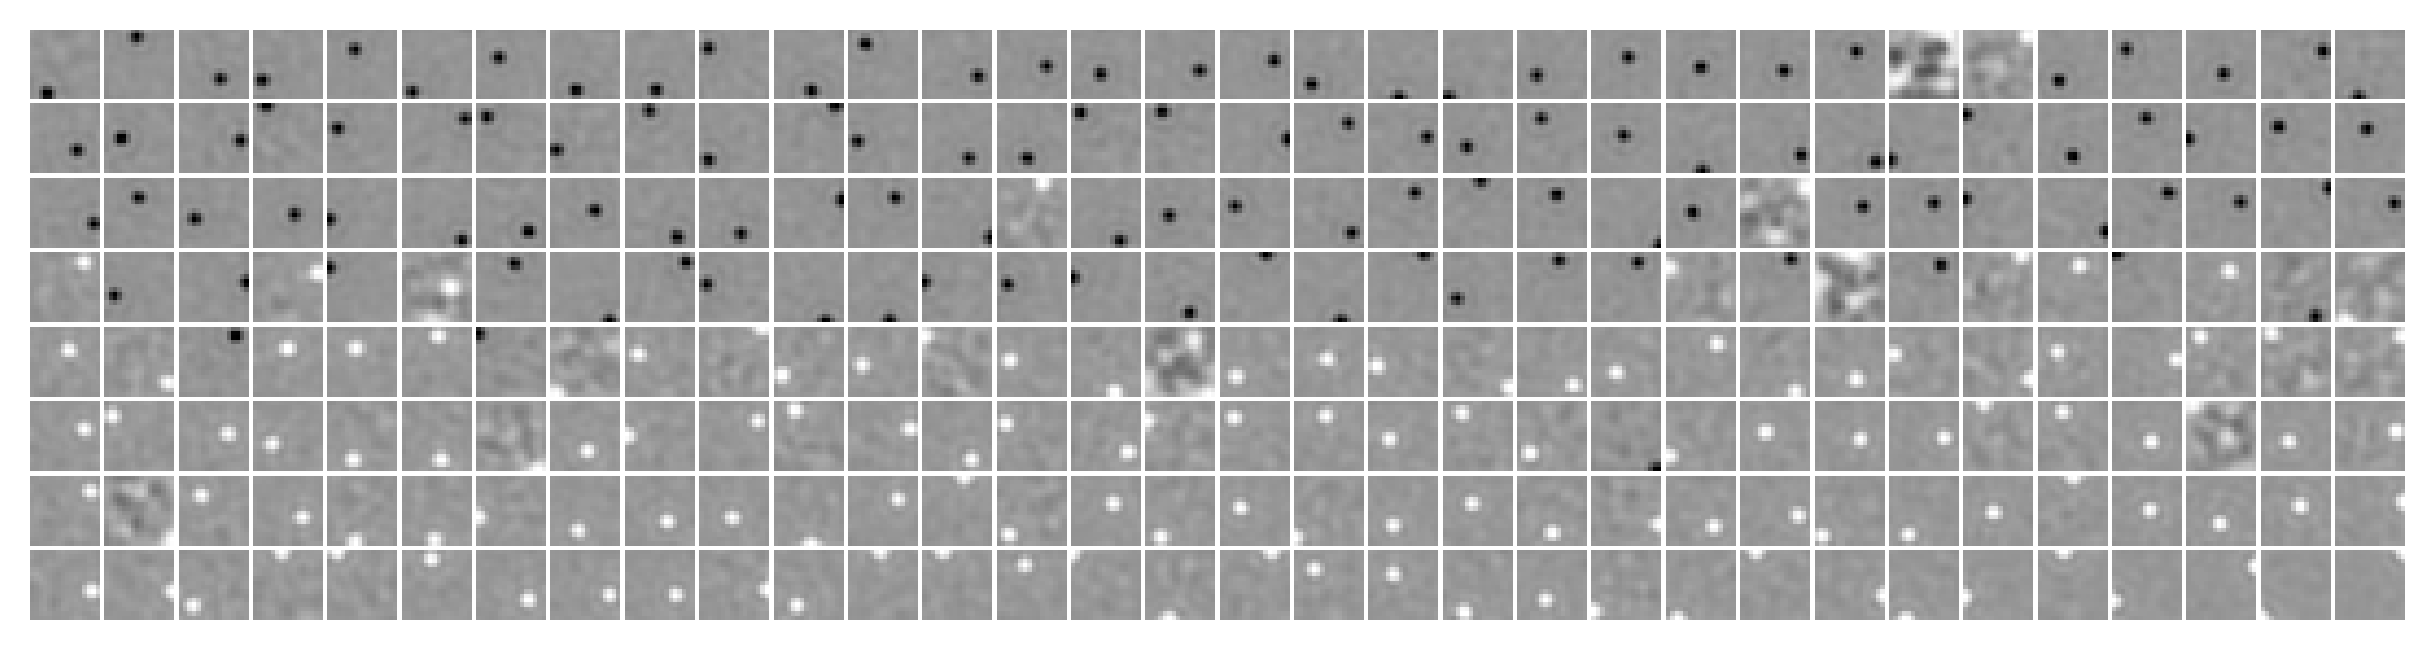

In [13]:
plot_weights(
    w=w_rescaled[np.argsort(u0)],
    method='none',
    vmin=0,
    vmax=1,
    cmap='Greys',
    nrows=8,
    dpi=300,
);

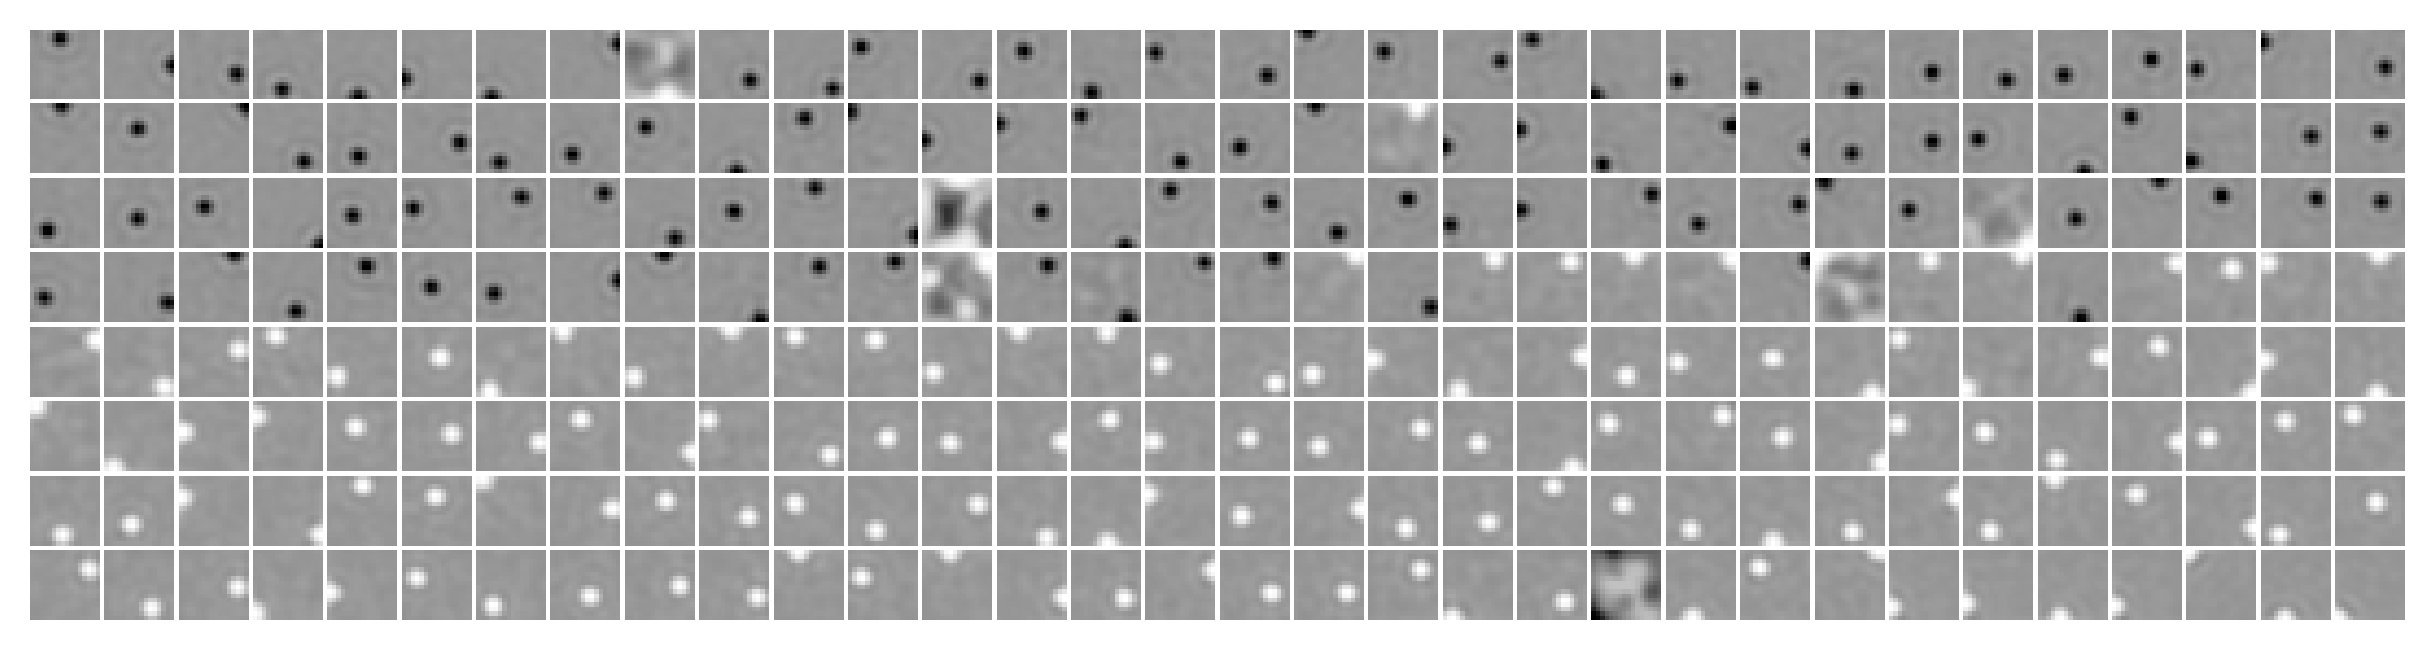

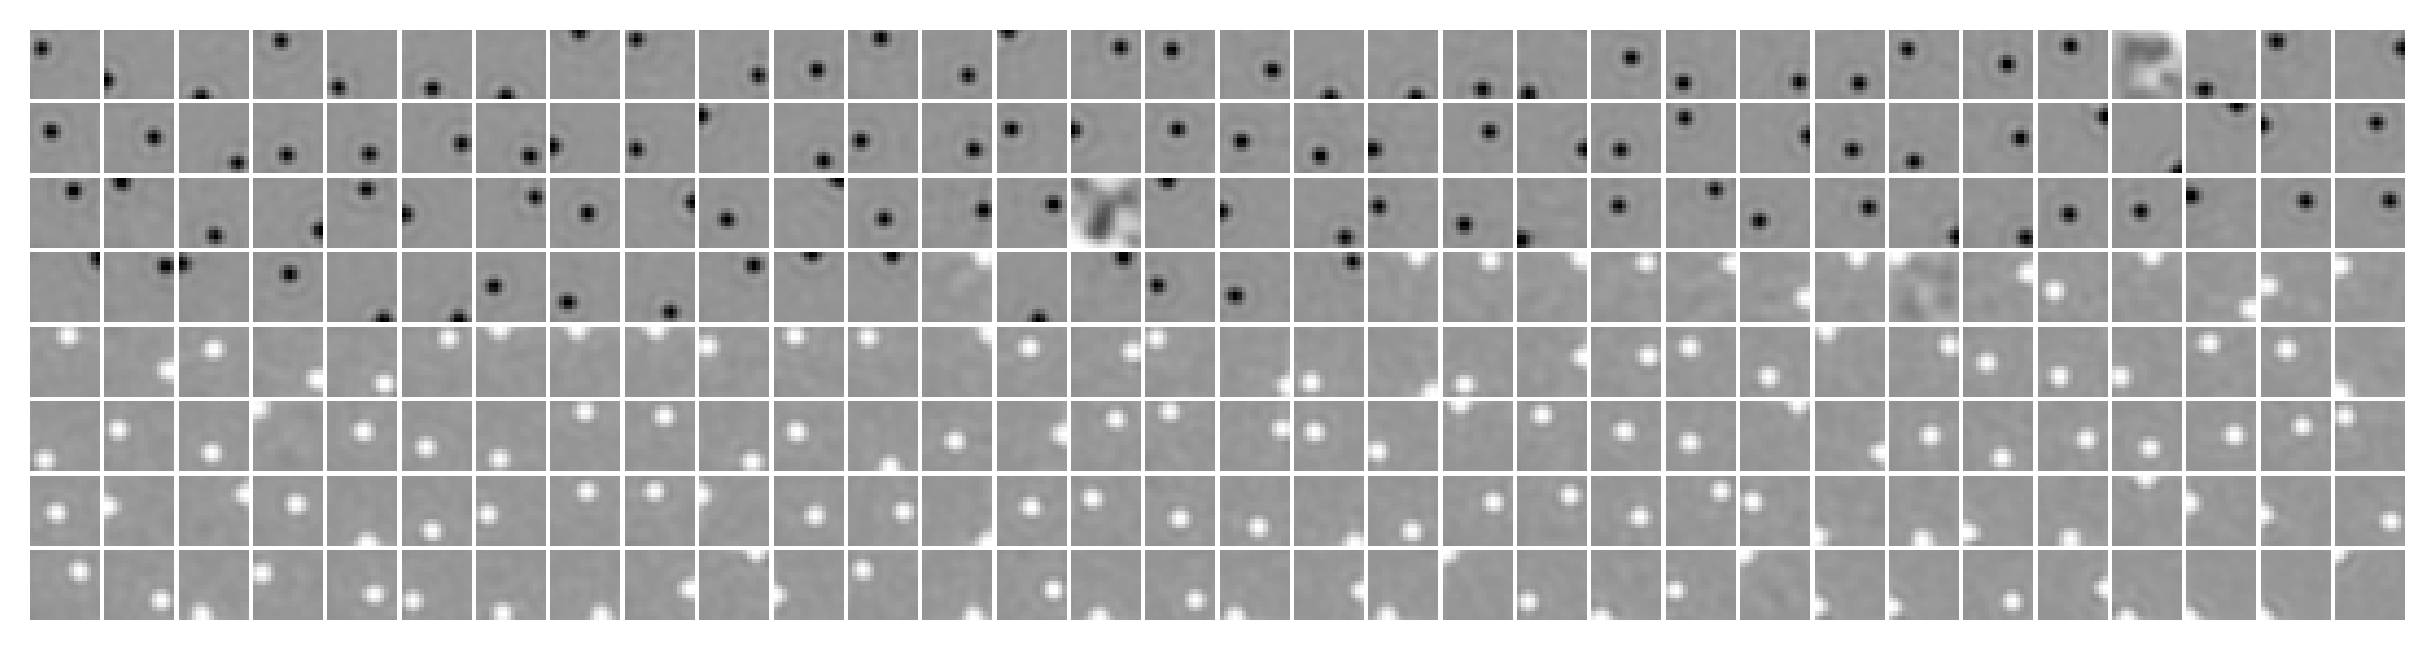

100%|███████████████████████████████████| 2/2 [00:27<00:00, 13.80s/it]


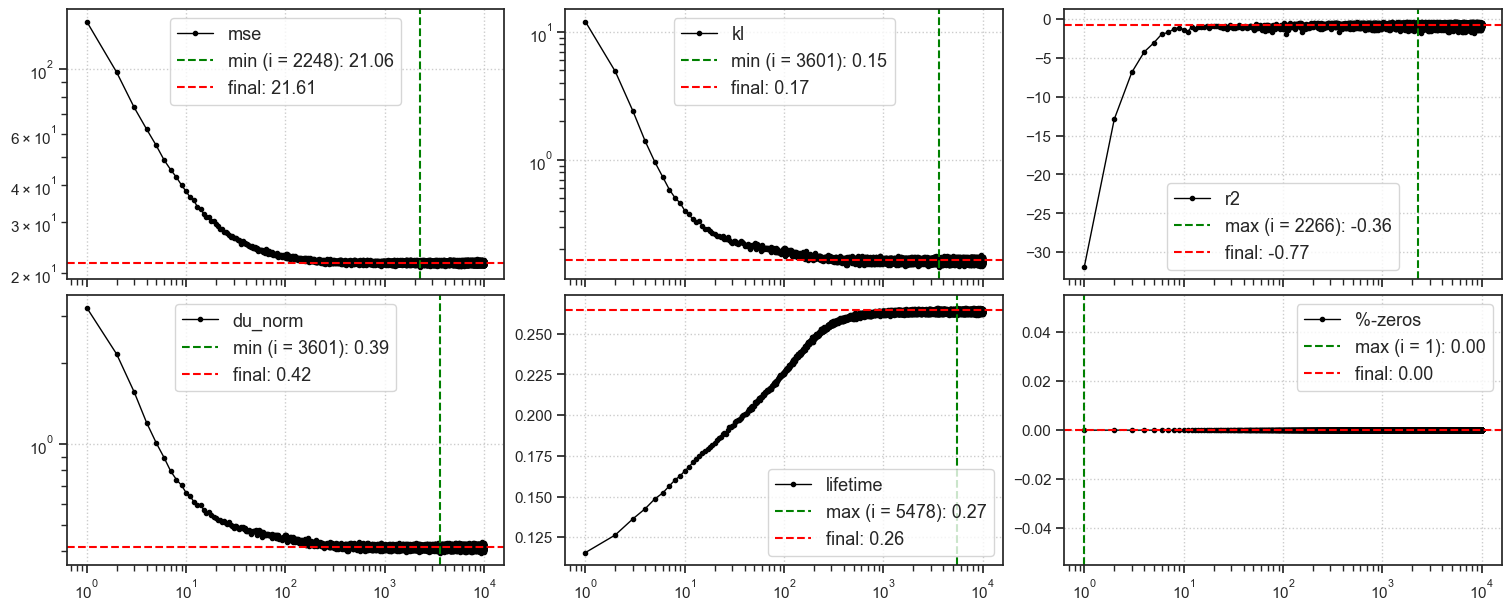

CPU times: user 33.1 s, sys: 1.34 s, total: 34.4 s
Wall time: 34.4 s


In [14]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

100%|███████████████████████████████████| 2/2 [00:27<00:00, 13.87s/it]


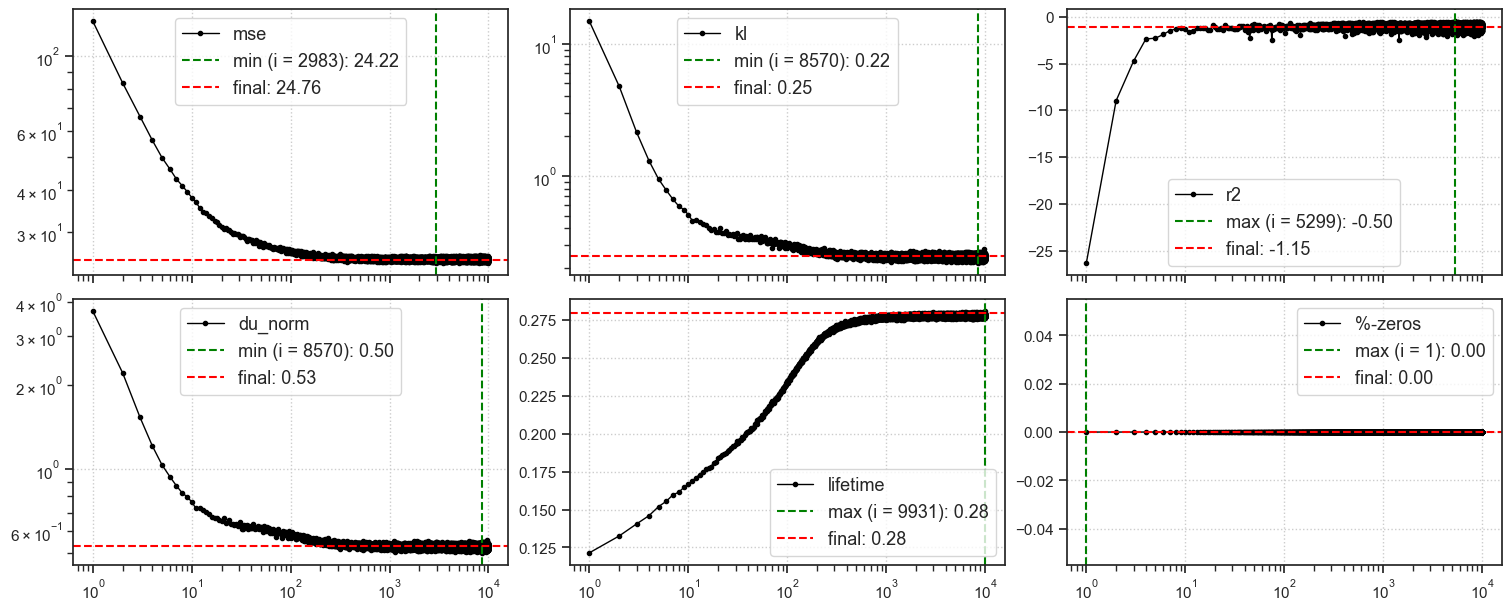

CPU times: user 33.1 s, sys: 1.52 s, total: 34.6 s
Wall time: 34.7 s


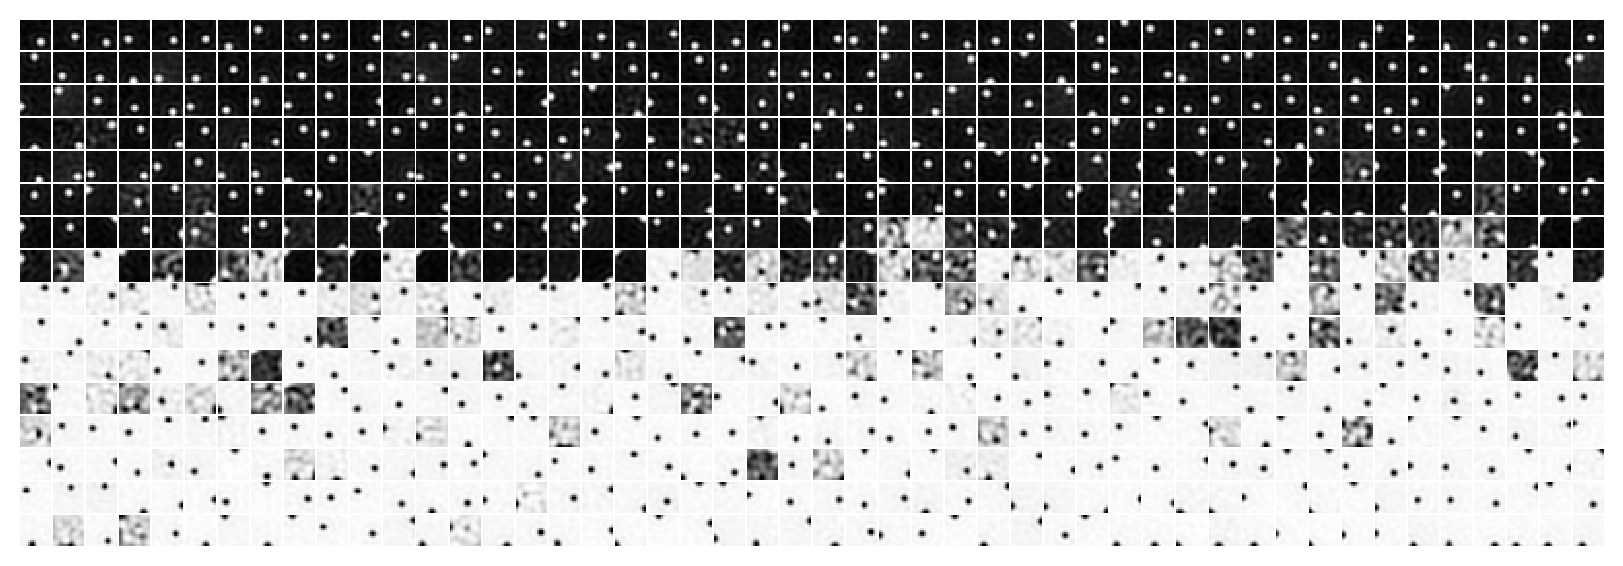

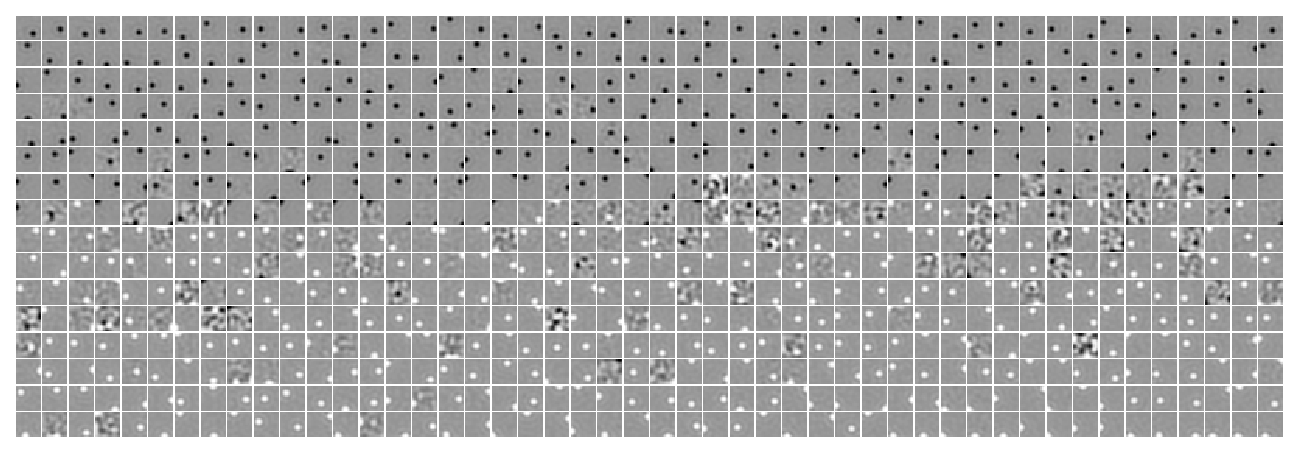

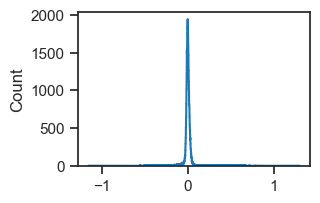

In [17]:
histplot(w.ravel())
plt.show()

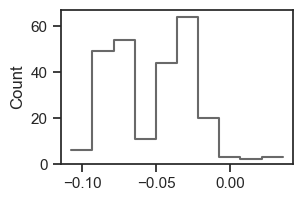

In [18]:
histplot(u0, color='dimgrey')
plt.show()

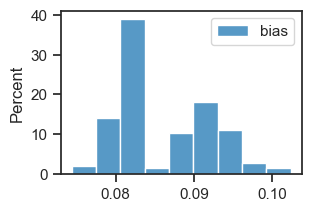

In [19]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

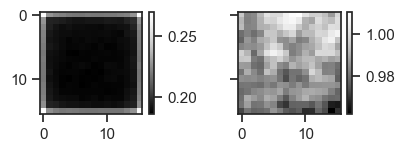

In [20]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:31<00:00, 15.90s/it]


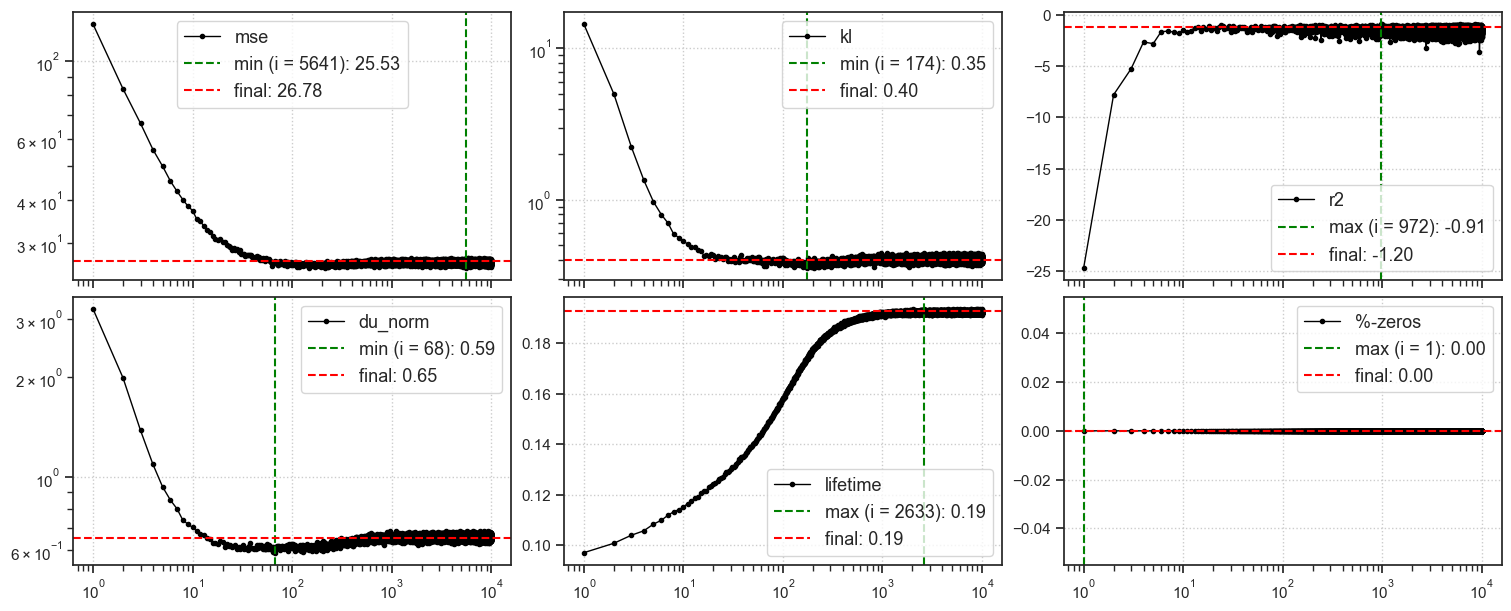

CPU times: user 44.7 s, sys: 4.69 s, total: 49.4 s
Wall time: 49.4 s


## Old model reproduce: z-768

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs(model_type, 'Kyoto16')

cfg_vae['n_latents'] = 512 + 256
cfg_vae['latent_act'] = 'sigmoid'

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 24.0

cfg_tr['kl_anneal_portion'] = 0.3
cfg_tr['lr'] = 0.002
cfg_tr['epochs']= 1000

cfg_tr['dataset_kws'] = {
    'file_name': 'patches.npy',
    'shift_rescale': True,
}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |  199.2 K   |
|     ———     |    ———     |
|    layer    |  199.2 K   |
+-------------+------------+

gaussian_sigmoid_Kyoto16_t-16_z-[768]_cl-5,5_<grad|lin>
b200-ep1000-lr(0.002)_beta(24:0.3)_gr(500)_(2025_03_03,13:54)

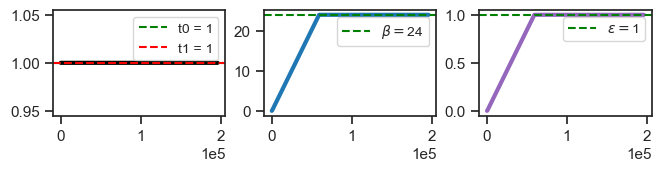

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

```python
gaussian_sigmoid_Kyoto16_t-16_z-[768]_cl-5,5_<grad|lin>  
non-whitened_b200-ep1000-lr(0.002)_beta(24:0.3)_gr(500)_(2025_02_26,13:54)
```

In [5]:
tr.n_iters

196000

In [6]:
tr.model.cfg.init_scale

0.0001

In [7]:
print(tr.model.layer)

GaussianSigmoidLayer(input_dim=256, latent_dim=768, temperature=1, beta_inner=1, eps=1)

In [8]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>),
 tensor([1.], device='cuda:0', grad_fn=<ExpBackward0>))

In [9]:
cm = f"cinit:2.0_cdec:4.6_initscale:1e-4_GradReconRevert"
tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

# tr.train()

epoch # 1000, avg loss: 200.922: 100%|████| 1000/1000 [2:29:14<00:00,  8.95s/it]


In [10]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0627], device='cuda:0', grad_fn=<ExpBackward0>),
 tensor([0.0049], device='cuda:0', grad_fn=<ExpBackward0>))

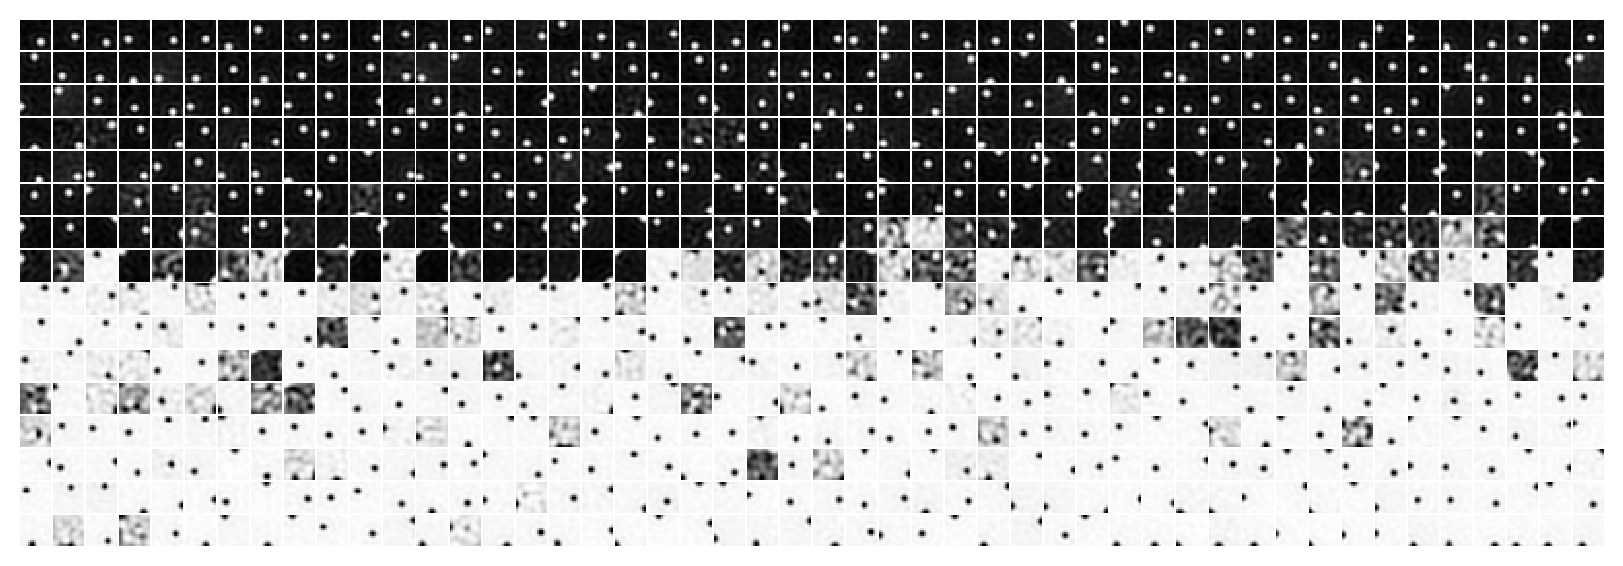

In [11]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16);

In [12]:
w = tr.model.layer.get_weight().T
absmax = torch.max(w.abs(), dim=1, keepdims=True).values

w_rescaled = 0.5 * (w / absmax + 1)
w_rescaled = w_rescaled.reshape(-1, 16, 16)

w_rescaled.shape

torch.Size([768, 16, 16])

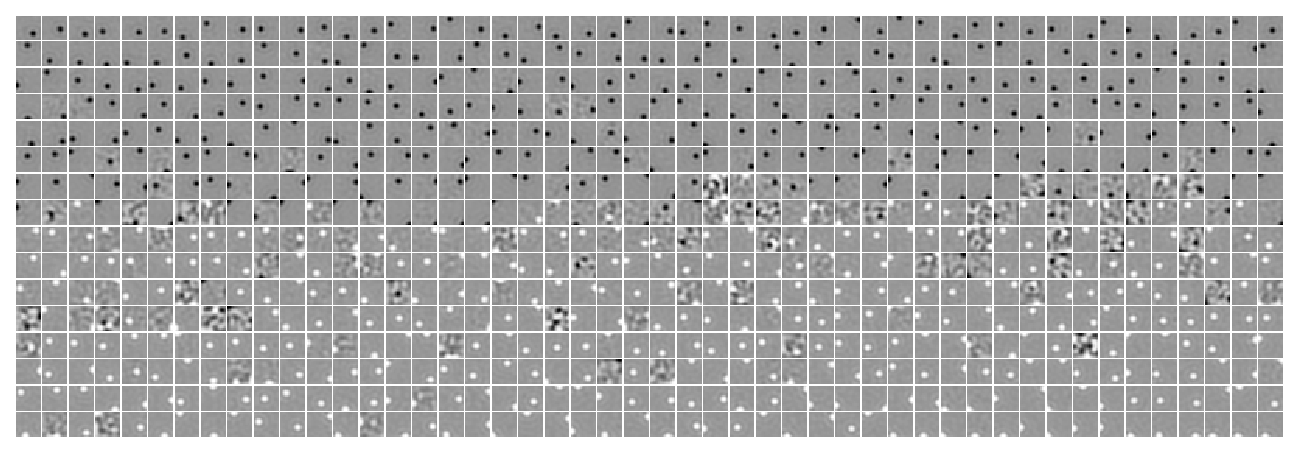

In [13]:
plot_weights(
    w=w_rescaled[np.argsort(u0)],
    method='none',
    vmin=0,
    vmax=1,
    cmap='Greys',
);

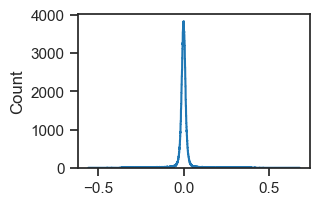

In [14]:
histplot(w.ravel())
plt.show()

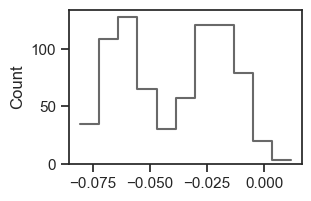

In [15]:
histplot(u0, color='dimgrey')
plt.show()

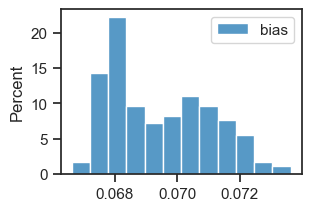

In [16]:
fig, ax = create_figure()

sns.histplot(tonp(tr.model.layer.log_bias.squeeze().exp()), label='bias', stat='percent',  ax=ax)
ax.legend()
plt.show()

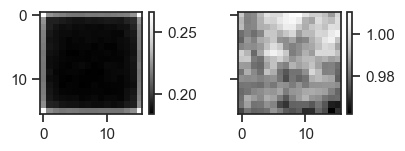

In [17]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

100%|███████████████████████████████████| 2/2 [00:31<00:00, 15.90s/it]


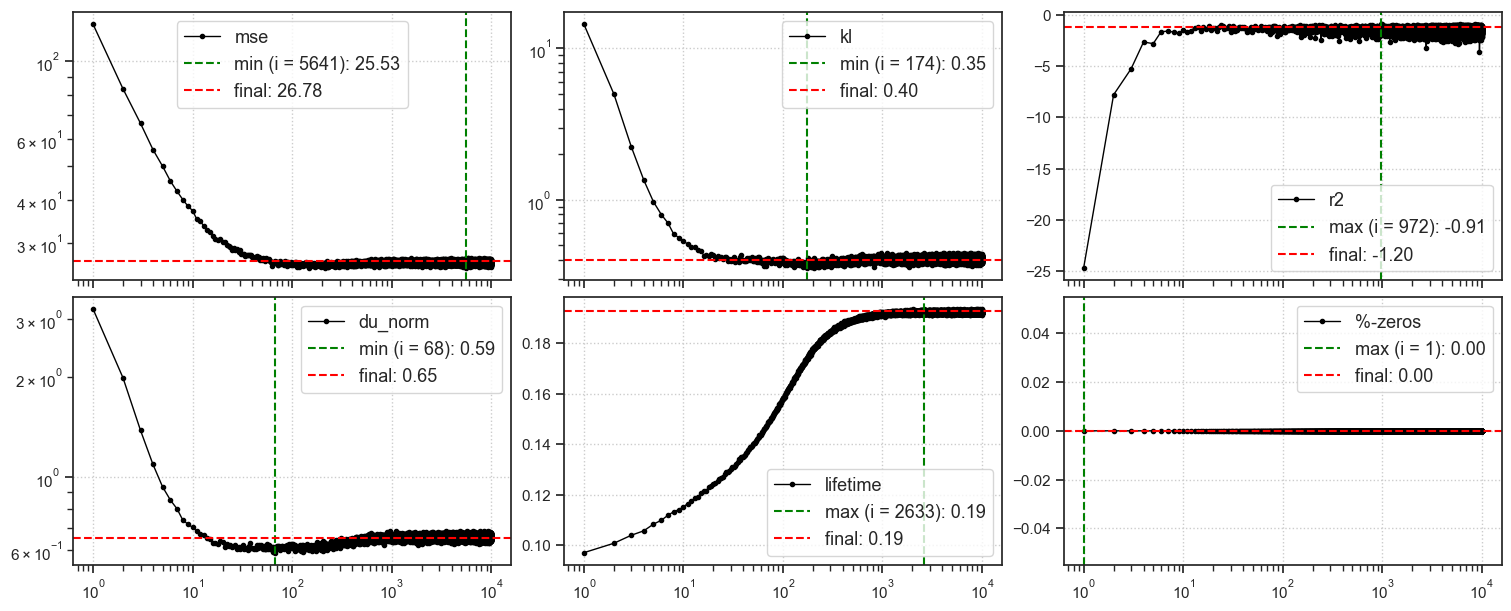

CPU times: user 44.7 s, sys: 4.69 s, total: 49.4 s
Wall time: 49.4 s


In [18]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')